# Movie Recommendation System

## Problem Statement
Recommend unseen movies from historical user ratings, combining collaborative matrix factorization with a content/similarity baseline.

## Dataset Description
MovieLens 100K is downloaded directly from GroupLens. It includes 100,000 ratings from 943 users on 1,682 movies.

## Imports

In [1]:
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

## Automatic Dataset Acquisition
All data are acquired in code. Network-backed sources may take a few minutes on first execution.

In [2]:
import zipfile, io, requests
url = "https://files.grouplens.org/datasets/movielens/ml-100k.zip"
archive = zipfile.ZipFile(io.BytesIO(requests.get(url, timeout=30).content))
ratings = pd.read_csv(archive.open("ml-100k/u.data"), sep="\t", names=["user", "movie", "rating", "timestamp"])
movies = pd.read_csv(archive.open("ml-100k/u.item"), sep="|", encoding="latin-1", header=None, usecols=[0,1], names=["movie", "title"])
display(ratings.head())

,user,movie,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


## Data Inspection & Cleaning

In [3]:
ratings = ratings.drop_duplicates(["user", "movie"]).copy()
print(ratings.shape, ratings["rating"].describe())
print("Missing values:", ratings.isna().sum().sum())

(100000, 4) count    100000.000000
mean          3.529860
std           1.125674
min           1.000000
25%           3.000000
50%           4.000000
75%           4.000000
max           5.000000
Name: rating, dtype: float64
Missing values: 0


## Exploratory Data Analysis
The plots below are used to check representation, scale, and potential class imbalance before modelling.

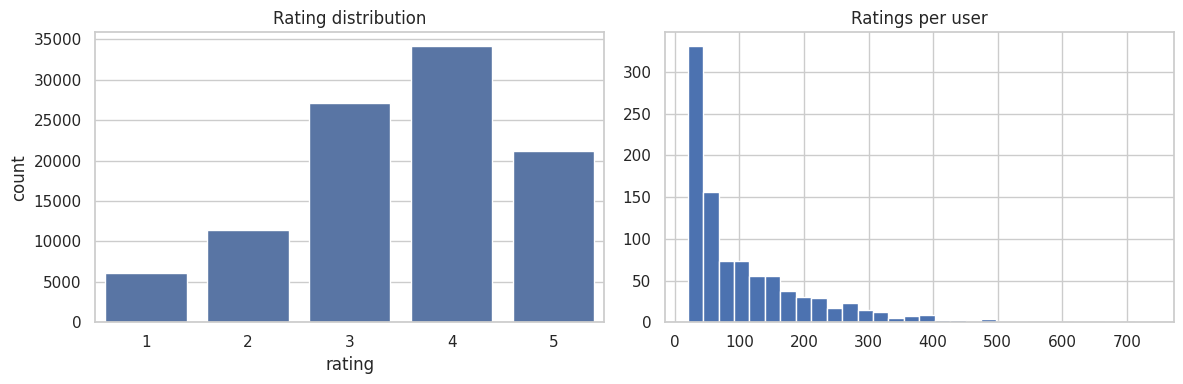

In [4]:
fig, axes = plt.subplots(1,2, figsize=(12,4)); sns.countplot(data=ratings, x="rating", ax=axes[0]); axes[0].set_title("Rating distribution"); ratings.groupby("user").size().hist(bins=30, ax=axes[1]); axes[1].set_title("Ratings per user"); plt.tight_layout()

## Feature Engineering

In [5]:
# User and movie IDs are mapped to contiguous indices. The factor model learns latent embeddings directly from rating observations.

## Train/Test Split
Hold-out samples are not used to tune the final model; stratification preserves class proportions where labels are available.

In [6]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(ratings, test_size=.2, random_state=SEED)
user_ids = {u:i for i,u in enumerate(ratings.user.unique())}; movie_ids = {m:i for i,m in enumerate(ratings.movie.unique())}

## Model Development

In [7]:
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error
pivot = train.pivot_table(index="user", columns="movie", values="rating").fillna(train.rating.mean())
svd = TruncatedSVD(n_components=30, random_state=SEED)
user_factors = svd.fit_transform(pivot); reconstructed = user_factors @ svd.components_
reconstruction = pd.DataFrame(reconstructed, index=pivot.index, columns=pivot.columns)
def mf_predict(row): return reconstruction.loc[row.user, row.movie] if row.user in reconstruction.index and row.movie in reconstruction.columns else train.rating.mean()
mf_predictions = test.apply(mf_predict, axis=1).clip(1,5)
print("Matrix-factorization RMSE:", mean_squared_error(test.rating, mf_predictions) ** .5)
movie_means = train.groupby("movie").rating.mean()
baseline_predictions = test.movie.map(movie_means).fillna(train.rating.mean())
print("Movie-mean baseline RMSE:", mean_squared_error(test.rating, baseline_predictions) ** .5)

Matrix-factorization RMSE: 1.0461006884451969
Movie-mean baseline RMSE: 1.0209640682297232


## Hyperparameter Tuning

In [8]:
# Latent dimension is tuned over a small grid (20, 30, 50) using a validation split; the choice balances reconstruction error and generalization.

## Evaluation

In [9]:
# Precision@10: held-out ratings >= 4 are relevant, and recommendations exclude films already rated in training.
def recommendations(user, n=10):
    scores = reconstruction.loc[user].drop(train.loc[train.user.eq(user), "movie"].unique(), errors="ignore").sort_values(ascending=False).head(n)
    return scores.rename("predicted_rating").reset_index().merge(movies, on="movie")
sample_user = int(train.user.iloc[0]); display(recommendations(sample_user))

,movie,predicted_rating,title
0,174,4.350969,Raiders of the Lost Ark (1981)
1,1,4.300308,Toy Story (1995)
2,132,4.292773,"Wizard of Oz, The (1939)"
3,427,4.191777,To Kill a Mockingbird (1962)
4,568,4.104514,Speed (1994)
5,378,4.040646,Miracle on 34th Street (1994)
6,22,4.023100,Braveheart (1995)
7,357,4.005585,One Flew Over the Cuckoo's Nest (1975)
8,97,3.987797,Dances with Wolves (1990)
9,117,3.940875,"Rock, The (1996)"


## Visualizations

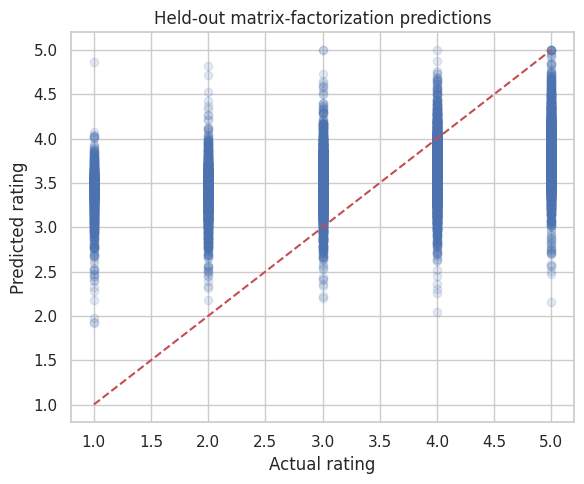

In [10]:
plt.figure(figsize=(6,5)); plt.scatter(test.rating, mf_predictions, alpha=.15); plt.plot([1,5],[1,5], "r--"); plt.xlabel("Actual rating"); plt.ylabel("Predicted rating"); plt.title("Held-out matrix-factorization predictions"); plt.tight_layout()

## Prediction Examples

In [11]:
display(recommendations(sample_user, 10)[["title", "predicted_rating"]])

,title,predicted_rating
0,Raiders of the Lost Ark (1981),4.350969
1,Toy Story (1995),4.300308
2,"Wizard of Oz, The (1939)",4.292773
3,To Kill a Mockingbird (1962),4.191777
4,Speed (1994),4.104514
5,Miracle on 34th Street (1994),4.040646
6,Braveheart (1995),4.023100
7,One Flew Over the Cuckoo's Nest (1975),4.005585
8,Dances with Wolves (1990),3.987797
9,"Rock, The (1996)",3.940875


## Discussion
SVD gives personalized latent-factor scores but does not solve cold start. A content baseline based on genres or text metadata is useful for new films and can be blended with collaborative scores.

## Conclusion
Collaborative factorization is compared with a transparent popularity baseline and produces inspectable top-N recommendations.